# Long-form inference experiments - analysis

## Imports and setup

In [4]:
# stdlib
import itertools
from multiprocessing import Pool
import os
from pathlib import Path

# third-party
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# first-party
from alt import util
import analyse

sns.set_theme()

util.default_log_config()

# Set up paths
project_root = Path(os.getcwd()).parent.parent
print(f"Home dir: {os.getenv('HOME')}")
print(f"Working dir: {os.getcwd()}")
print(f"Project root: {project_root}")

Home dir: /homes/js231
Working dir: /homes/js231/code/alt/expt/01-ss
Project root: /homes/js231/code/alt


## Prepare data

In [5]:
# Define datasets and models
data = {}
models = ["whisper"]
algos = ["base", "rmsvad"]
audios = ["original", "separated", "stem"]

DEMUCS_MODEL_NAME="mdx_extra"
NUM_ITERATIONS = 5

for model, audio, algo in tqdm(list(itertools.product(models, audios, algos))):
    if audio == "separated" or algo == "rmsvad":
        name = f"01-long-{DEMUCS_MODEL_NAME}-{model}-{audio}-{algo}"
    else:
        name = f"01-long-{model}-{audio}-base"

    data[(model, audio, algo)] = []
    for idx in range(NUM_ITERATIONS):
        name_idx = f"{name}-{idx}"
        uids = util.read_summary(f"../../build/{name_idx}/infer/summary.json").infer.uids  # type: ignore
        uids = [uid for uid in uids if uid.endswith("jam-alt") or uid.endswith("musdb-alt")]
        results= Pool(20).starmap(
            analyse.eval_song, [(name_idx, uid) for uid in uids]
        )
        data[(model, audio, algo)].extend(results)


100%|██████████| 6/6 [01:04<00:00, 10.75s/it]


## Convert to DataFrames

In [6]:
# Process data into DataFrames
df_samples, df_chunks, df_edits = analyse.process_data(data, ("model", "audio", "algo"), num_workers=20)

# Save processed data
util.write_pz(project_root / "share" / "data_long.pz", (df_samples, df_chunks, df_edits))

100%|██████████| 6/6 [00:23<00:00,  4.00s/it]


## Load and analyze data

In [7]:
# Load processed data
(df_songs, df_chunks, df_edits) = util.read_pz(project_root / "share" / "data_long.pz")

## Summary statistics

In [8]:
import librosa
def get_duration(audio_fn: str):
    y, sr = librosa.load(audio_fn, sr=None)  # sr=None ensures the original sample rate is used
    return librosa.get_duration(y=y, sr=sr)

df = df_songs.query("model == 'whisper' and algo == 'rmsvad' and audio == 'original'").copy()
df["len"] = df["hit"] + df["sub"] + df["del"]
df["nl"] = df["hit_nl"] + df["sub_nl"] + df["del_nl"]
df["bv"] = df["hit_bv"] + df["sub_bv"] + df["del_bv"]

# Group by 'dataset' and calculate metrics
result = df.groupby('dataset').agg(
    num_unique_uid=('uid', 'nunique'),  # Number of unique uids
    total_duration_mins=('duration', lambda x: x.sum() / 60),  # Total duration in minutes
    nl_len_percent=('nl', lambda x: (x.sum() / df.loc[x.index, 'len'].sum()) * 100),  # nl/len %
    bv_len_percent=('bv', lambda x: (x.sum() / df.loc[x.index, 'len'].sum()) * 100)  # bv/len %
).reset_index()

# Rename columns for clarity
result.columns = ['dataset', 'num_unique_uid', 'total_duration (mins)', 'nl/len %', 'bv/len %']
result = result.round(2)

# Display the result
display(result)

,dataset,num_unique_uid,total_duration (mins),nl/len %,bv/len %
0,jam-alt,79,1416.47,4.68,4.66
1,musdb-alt,39,831.69,3.27,4.90


## Results Table

In [9]:
rename_dict = {
    "hit_r": "HR",
    "sub_r": "SR",
    "del_r": "DR",
    "ins_r": "IR",
    "wer": "WER",
    "hal_r": "IR_Hal",
    "del_nl_r": "DR_NL",
    "del_bv_r": "DR_BV",
}
rename_dict_dataset = {
    "jam-alt": "JAM-ALT",
    "musdb-alt": "MUSDB-ALT",
}
rename_dict_algo = {
    "base": "Default",
    "rmsvad": "RMS-VAD",
}
rename_dict_target = {
    "original": "Original Mix",
    "separated": "Separated Vocals",
    "stem": "Vocal Stem",
}
for model in ["whisper"]:
    df = df_chunks.query("model == @model and algo !='verse'").copy()
    df["hit"] = (df["typ"] == "hit") * df["len"]
    df["sub"] = (df["typ"] == "sub") * df["len"]
    df["ins"] = (df["typ"] == "ins") * df["len"]
    df["del"] = (df["typ"] == "del") * df["len"]
    df["hal"] = (df["ins"] > 10) * df["ins"] + (df["sub"] > 10) * df["sub"]
    df["del_nl"] = (df["typ"] == "del") * df["nl"]
    df["del_bv"] = (df["typ"] == "del") * df["bv"]
    pivot_table = (
        df.groupby(["audio", "algo", "dataset"])[["sub", "hit", "del", "ins", "hal", "del_nl", "del_bv"]]
        .sum()
        .assign(
            sub_r=lambda df: df["sub"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            ins_r=lambda df: df["ins"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_r=lambda df: df["del"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            wer=lambda df: (df["sub"] + df["ins"] + df["del"])
            / (df["hit"] + df["sub"] + df["del"])
            * 100,
            hal_r=lambda df: (df["hal"]) / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_nl_r=lambda df: df["del_nl"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_bv_r=lambda df: df["del_bv"] / (df["hit"] + df["sub"] + df["del"]) * 100,
        )
        .reset_index()
        .pivot(
            index=["audio", "algo"],
            columns=["dataset"],
            values=["wer", "sub_r", "del_r", "ins_r", "hal_r", "del_nl_r", "del_bv_r"],
        )
        .swaplevel(0, 1, axis=1)
        .sort_index(axis=1, level=0, sort_remaining=False)
        .rename(columns=rename_dict, level=1)
        .rename(columns=rename_dict_dataset, level=0)
        .rename(index=rename_dict_algo, level=1)
        .rename(index=rename_dict_target, level=0)
        .rename_axis(
            index={"audio": "Audio", "algo": "Algorithm"}, columns={"dataset": "Dataset"}
        )
    )

    table_styles = [
        {'selector': 'toprule', 'props': ':\\toprule;'},
        {'selector': 'midrule', 'props': ':\\hline;'},
        {'selector': 'bottomrule', 'props': ':\\bottomrule;'},
    ]
    pivot_table = (pivot_table.style.format(
            "{:.2f}",
            na_rep="-",
            subset=pd.IndexSlice[:, pd.IndexSlice[:, ["WER", "SR", "DR", "IR", "IR_Hal", "DR_NL", "DR_BV"]]],
        )
        # .format("{:.0f}", na_rep="-", subset=pd.IndexSlice[:, pd.IndexSlice[:, ["H-5G"]]])
        .highlight_min(
            props="font-weight:bold;",
            subset = pd.IndexSlice[pd.IndexSlice[["Original Mix", "Separated Vocals"]], :]
        )
    )
    display( pivot_table) 

    latex_table = pivot_table.format_index(escape="latex").format_index(
        escape="latex", axis=1
    ).to_latex(convert_css=True)
    (project_root / "share" / "long_error_table.tex").write_text(
        latex_table
    )

## WER box plots

whisper: Mean WERs


/tmp/ipykernel_625837/2690342191.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_wer)


/tmp/ipykernel_625837/2690342191.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
/tmp/ipykernel_625837/2690342191.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)


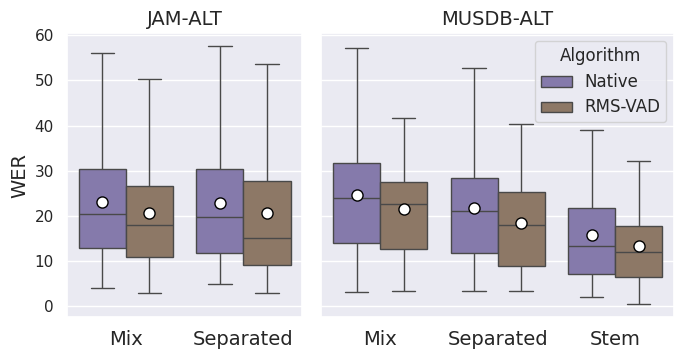

In [10]:
def combine_wer(rows):
    hit = rows["hit"].sum()
    ins = rows["ins"].sum()
    dels = rows["del"].sum()
    sub = rows["sub"].sum()
    wer = (ins + sub + dels) / (hit + sub + dels)
    return wer


pivot_table = (
    df_songs.groupby(["dataset", "audio", "algo"])
    .apply(combine_wer)
    .reset_index(name="wer")
    .pivot(index=["dataset", "audio"], columns="algo", values="wer")
    .reindex(["jam-alt", "musdb-alt"], level=0)
    .reindex(["original", "separated", "stem"], level=1)
)
print(f"{model}: Mean WERs")
display((pivot_table * 100).style.format("{:.2f}"))

plot_data = (df_songs
    .query("model == @model and algo != 'verse'")
    .replace({"algo": {"base": "Native", "rmsvad": "RMS-VAD", "verse": "Groups"}})
    .rename(columns={"algo": "Algorithm"})
    .replace({"audio": {"original" : "Mix", "separated": "Separated", "stem": "Stem"}})
    .rename(columns={"audio": "Audio"})
)

fig, axes = plt.subplots(1, 2, figsize=(7,3.75), sharey=True, gridspec_kw={"width_ratios": [2,3]})
datasets = ["jam-alt", "musdb-alt"]
colors = sns.color_palette()
for ax, dataset in zip(axes, datasets):
    data = plot_data.query("dataset==@dataset").copy()
    data["wer"] *= 100
    sns.boxplot(
        data=data,
        x="Audio",
        y="wer",
        hue="Algorithm",
        ax=ax,
        showmeans=True,
        showfliers=False,
        palette=[colors[4], colors[5]],
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8",
        },
    )
    fs = 14
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
    ax.set_title(dataset.upper(), fontsize=fs)
    ax.set_ylabel("WER", fontsize=fs)
    ax.get_xaxis().label.set_visible(False)
    # ax.set_xlabel("Audio", fontsize=fs)
    # ax.set_ylim(-0.01, 1)
axes[1].legend_.set_title("Algorithm")
for text in axes[1].legend_.get_texts():
    text.set_fontsize(fs-2)
axes[0].legend_.remove()

plt.tight_layout()
fig.savefig(project_root / "share" / "long_wer_box.pdf")
plt.show()

## Results table by language

In [13]:
def combine_wer(rows):
    rows = rows.query("not(typ in ['ins', 'sub'] and len > 15)")
    rows = rows.groupby("typ")["len"].sum()
    hit = rows["hit"]
    ins = rows["ins"]
    dels = rows["del"]
    sub = rows["sub"]
    wer = (ins + sub + dels) / (hit + sub + dels)
    return wer


pivot_table = (
    df_chunks.query("dataset == 'jam-alt'")
    .groupby(["audio", "algo", "language"])
    .apply(combine_wer)
    .reset_index(name="wer")
    .pivot(index=["audio", "algo"], columns="language", values="wer")
)
# Add a new row for "lyricwhiz"
lyricwhiz_row = pd.DataFrame(
    {"en": [0.237]},
    index=pd.MultiIndex.from_tuples([("lyricwhiz", "")], names=["audio", "algo"]),
)
pivot_table = pd.concat([pivot_table, lyricwhiz_row])
pivot_table = (
    (pivot_table * 100)
    .style.format("{:.2f}", na_rep="-", escape="latex")
    .format_index(escape="latex")
    .highlight_min(axis=0, props="font-weight:bold;", subset=pd.IndexSlice[pd.IndexSlice[:, :], pivot_table.columns.difference([("lyricwhiz", "")])])
    .set_table_styles(
        [
            {"selector": "toprule", "props": ":hline;"},
            {"selector": "midrule", "props": ":hline;"},
            {"selector": "bottomrule", "props": ":hline;"},
            {"selector": "thead", "props": [("border-bottom", "2px solid black")]},
            {
                "selector": "tbody tr:last-of-type",
                "props": [("border-top", "2px solid black")],
            },
        ],
        overwrite=False,
    )
)
display(pivot_table)
latex_table = pivot_table.to_latex(
    hrules=True, clines="all;data", column_format="|l|" + "r|" * 5, convert_css="true"
)
print(latex_table)
(project_root / "share" / "long_error_table_lang.tex").write_text(latex_table)
# pivot_table.plot(kind="bar", title=model)

/tmp/ipykernel_625837/3578283965.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_wer)


\begin{table}
\thead2px solid black
\tbody tr:last-of-type2px solid black
\begin{tabular}{|l|r|r|r|r|r|}
\toprule
 &  & de & en & es & fr \\
audio & algo &  &  &  &  \\
\midrule
\multirow[c]{2}{*}{original} & base & 17.58 & 27.05 & 16.80 & 25.21 \\
\cline{2-6}
 & rmsvad & 15.90 & 24.26 & \bfseries 14.78 & 23.80 \\
\cline{1-6} \cline{2-6}
\multirow[c]{2}{*}{separated} & base & 16.68 & 24.24 & 19.05 & 24.76 \\
\cline{2-6}
 & rmsvad & \bfseries 12.85 & 23.89 & 18.60 & \bfseries 23.72 \\
\cline{1-6} \cline{2-6}
lyricwhiz &  & - & \bfseries 23.70 & - & - \\
\cline{1-6} \cline{2-6}
\bottomrule
\end{tabular}
\end{table}



621